In [1]:
from lokigi.site import SiteProblem

problem = SiteProblem()

problem.add_sites(
    "../../../sample_data/devon_cdcs.csv",
    candidate_id_col="Facility_Name",
    vertical_geometry_col="Latitude",
    horizontal_geometry_col="Longitude",
    required_sites_col="Existing"
    )

problem.add_region_geometry_layer(
    "../../../sample_data/LSOA_Devon_2021_EW_BSC_V4.gpkg",
    common_col="LSOA21NM"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/travel_matrix_car_devon_cdcs.csv",
    source_col="from_id",
    unit="minutes",
    )

problem.add_demand(
    "../../../sample_data/demand_MF_50_84.csv",
    demand_col="Total",
    location_id_col="LSOA 2021 Name"
    )

problem.add_equity_data(
    "../../../sample_data/devon_imd_2025_2021_LSOAs.csv",
    equity_col="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA",
    common_col="LSOA name (2021)",
    label="IMD Decile (1 = most deprived)"
    )

Guessed CRS: EPSG:4326 (Values fall within longitude/latitude bounds)


<Axes: >

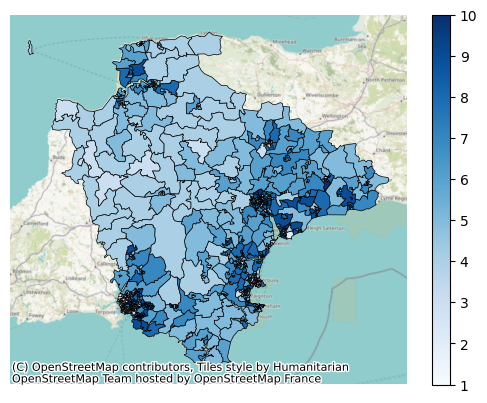

In [2]:
problem.plot_region_geometry_layer(plot_equity=True)

<Axes: >

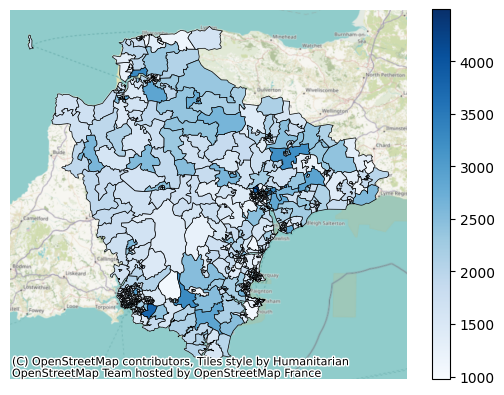

In [3]:
problem.plot_region_geometry_layer(plot_demand=True)

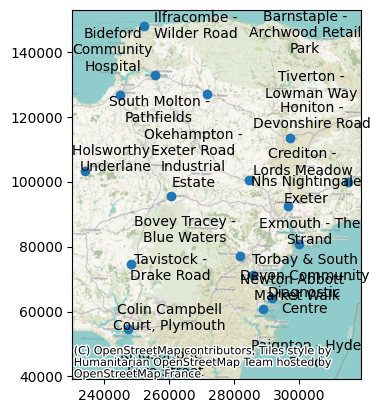

In [4]:
problem.plot_sites()

# Weighting by demand, equity, or both

The default behaviour in lokigi, if no weights are stated for a standard (unsimplified) p-median problem

As a reminder, an unsimplified p-median problem will solve for raw travel times rather than applying any weighting. 

In [5]:
solution_standard_demand_weighted_p_median = problem.solve(p=5, objectives="p_median")
solution_standard_demand_weighted_p_median.show_solutions(n_best=3)

  0%|          | 0/14 [00:00<?, ?it/s]

Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand': 1.0}
Falling back to default: weighting p-median by demand only
Weights: {'demand

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 12]",None,20.23,20.03,39.41,61.53,0.0,LSOA 2021 Name Bideford Community Hospi...
1,2,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5]",None,20.43,20.37,37.61,61.53,0.0,LSOA 2021 Name Bideford Community Hospi...
2,3,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 8]",None,20.44,20.21,42.07,61.18,0.0,LSOA 2021 Name Bideford Community Hospi...


## Weighting by equity instead

We can instead weight by equity by passing in a dictionary of weights. 

In [6]:
solution_equity_weighted_p_median = problem.solve(p=5, objectives="p_median", weights={'equity': 1.0})
solution_equity_weighted_p_median.show_solutions(n_best=3)

  0%|          | 0/14 [00:00<?, ?it/s]

Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}
Weighting p-median by custom options
Weights: {'equity': 1.0}


,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 12]",None,19.57,20.03,39.41,61.53,0.0,LSOA 2021 Name Bideford Community Hospi...
1,2,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5]",None,19.91,20.37,37.61,61.53,0.0,LSOA 2021 Name Bideford Community Hospi...
2,3,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 17]",None,19.99,20.37,41.91,61.18,0.0,LSOA 2021 Name Bideford Community Hospi...


## Weighting by both demand and equity

In [7]:
solution_equity_and_demand_weighted_p_median = problem.solve(
    p=5, objectives="p_median", weights={'equity': 1.0, 'demand': 1.0}
    )
solution_equity_and_demand_weighted_p_median.show_solutions(n_best=3)

  0%|          | 0/14 [00:00<?, ?it/s]

Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}
Weighting p-median by custom options
Weights: {'equity': 0.5, 'demand': 0.5}

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 12]",None,19.84,20.03,39.41,61.53,0.0,LSOA 2021 Name Bideford Community Hospi...
1,2,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5]",None,20.08,20.37,37.61,61.53,0.0,LSOA 2021 Name Bideford Community Hospi...
2,3,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 4]",None,20.17,20.39,41.07,61.53,0.0,LSOA 2021 Name Bideford Community Hospi...


# Additional datasets

Let's now add an additional dataset. We're going to add in demand for patients 50-84. 

In [8]:
problem.add_additional_data(
    df="../../../sample_data/demand_MF_50_84.csv",
    column_of_interest="MF50-84",
    common_col="LSOA 2021 Name",
    label="Demand 50-84",
    direction="higher_better"
    )

C:\lokigi\lokigi\problem.py:567: UserWarning: Provided common col not found in the region geometry or site dataset.You can ignore this warning if you haven't provided those datasets yet.
  warn(


AttributeError: 'NoneType' object has no attribute 'append'

In [ ]:
solution_equity_and_demand_weighted_p_median = problem.solve(
    p=5, objectives="p_median", weights={'equity': 0.1, 'demand': 0.1, 'demand_50_84': 0.6}
    )
solution_equity_and_demand_weighted_p_median.show_solutions(n_best=3)